# Quora Question Pairs - Duplicate Question Detection
### Advanced NLP & Gradient Boosting Classification Pipeline (GPU-Accelerated)

This notebook implements an end-to-end Machine Learning pipeline to identify duplicate question pairs from Quora. Duplicate question detection is a crucial task for Q&A platforms to improve search, prevent redundant answers, and group similar content.

#### Key Processing Stages:
1. **Environment Setup & Packages**: Installing required external packages and downloading datasets.
2. **GPU-Accelerated Text Preprocessing**: Lowercasing, HTML/URL stripping, emoji cleaning, contraction expansion, and tokenization using RAPIDS `cuDF`.
3. **Tabular Feature Engineering**:
   - **Basic Features**: Character lengths, token counts, and differences.
   - **Semantic Features**: Intersection of unique words, stopword ratios, and first/last word matches.
   - **Fuzzy Distance Metrics**: RapidFuzz similarity ratios (ratio, partial ratio, token sort, token set).
4. **Dense Word Embeddings**: Word2Vec embeddings (Google News 300) aggregated to sentence representations.
5. **Hyperparameter Tuning (Optuna)**: Tuning GBDT models (LightGBM, XGBoost, CatBoost), HistGradientBoosting, and SGD.
6. **Artifact Serialization**: Saving the winning model, scaler, and final production inference script.

## 1. Environment Setup & Dependency Installation
We install the external libraries required for high-performance string matching (`rapidfuzz`), similarity visualization (`hvplot`), hyperparameter optimization (`optuna`), and fast gradient boosting (`catboost`).

In [37]:
# Install dependencies for plotting, fuzzy matching, hyperparameter optimization, and modeling
!pip install -q hvplot rapidfuzz distance optuna catboost gensim

## 2. Kaggle API Credentials Setup
Create the local `.kaggle` directory and write credentials for pulling datasets directly using `kagglehub`.

In [38]:
# Set up Kaggle access token credentials directory
!mkdir -p ~/.kaggle && echo KGAT_66bd6c6d0c7d94db2f6ed4e4a9a205b1 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

## 3. Library Imports & Configuration
Load core libraries: `pandas`/`numpy` for CPU tabular processing, RAPIDS `cuDF`/`cuPy` for GPU-accelerated array and string ops, visualizers, parallel execution engines, NLP resources, and classification algorithms.

In [39]:
# ==============================================================================
# IMPORT CORE MODULES AND MACHINE LEARNING LIBRARIES
# ==============================================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import gc
import time
import shutil
from collections import Counter

# Robust RAPIDS GPU-acceleration check
try:
    import cudf
    import cupy as cp
    import hvplot.cudf
    HAS_GPU = True
except ImportError:
    HAS_GPU = False
    print("RAPIDS cuDF/cuPy not found. Falling back to CPU (Pandas/NumPy).")

import holoviews as hv
import hvplot.pandas
from holoviews import opts
from tqdm import tqdm
from rapidfuzz import fuzz
import joblib
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
from concurrent.futures import ThreadPoolExecutor

import optuna
import warnings
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

hv.extension('bokeh')

# NLP libraries
import nltk
from nltk.corpus import stopwords
import distance
import gensim.downloader as api

# Download NLTK data
nltk.download('stopwords')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# XGBoost
from xgboost import XGBClassifier

# PyTorch (deep learning baseline, see section 20)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import kagglehub


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 4. Download Competition Dataset
Use `kagglehub` to download the Quora Question Pairs competition dataset files dynamically.

In [40]:
# Download the latest Quora Question Pairs files from Kaggle
path = kagglehub.competition_download('quora-question-pairs')
print("Path to competition files:", path)


Path to competition files: /root/.cache/kagglehub/competitions/quora-question-pairs


## 5. Extract and Transfer Dataset Files
Copy files from the kagglehub cache directory to the working `/content` directory.

In [41]:
# Copy the downloaded dataset folder contents to /content or local directory
data_dir = "/content" if os.path.exists("/content") else "./content"
src = path
shutil.copytree(src, data_dir, dirs_exist_ok=True)


'/content'

## 6. Load Dataset and Initial Inspection
Load the training dataset into a Pandas DataFrame and view the first few records.

In [42]:
# Load compressed CSV data and view the structure of the training dataset
df = pd.read_csv(os.path.join(data_dir, "train.csv.zip"))
# df = df.sample(1000, random_state=42)
df.head()


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


## 7. Handle Missing Values
Filter out records containing missing text strings in either question column to prevent failures in downstream preprocessing.

In [43]:
# Drop missing question records in place
df.dropna(inplace=True)

## 8. GPU-Accelerated Text Preprocessing
We define a high-performance preprocessing routine `preprocess_gpu` executing on RAPIDS `cuDF` Series. The pipeline performs lowercasing, HTML tags/URL cleaning, contraction resolution, symbol normalization, punctuation removal, and white-space collapsing on the GPU.

In [44]:
# Convert pandas DataFrame to GPU DataFrame or run CPU preprocessing based on availability
def preprocess_gpu(series):
    series = series.astype(str)

    # Lowercase + strip
    series = series.str.lower().str.strip()

    # Remove emojis
    emoji_pattern = (
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+"
    )
    series = series.str.replace(emoji_pattern, "", regex=True)

    # Remove HTML tags
    series = series.str.replace(r"<.*?>", "", regex=True)

    # Remove URLs
    series = series.str.replace(r"https?://\S+|www\.\S+", "", regex=True)

    # Replace symbols
    replacements = {
        "%":      " percent ",
        "$":      " dollar ",
        "₹":      " rupee ",
        "€":      " euro ",
        "@":      " at ",
        "[math]": "",
    }
    for old, new in replacements.items():
        series = series.str.replace(old, new, regex=False)

    # Expand contractions
    contractions = {
        "ain't": "am not", "aren't": "are not", "can't": "can not",
        "can't've": "can not have", "'cause": "because",
        "could've": "could have", "couldn't": "could not",
        "couldn't've": "could not have", "didn't": "did not",
        "doesn't": "does not", "don't": "do not", "hadn't": "had not",
        "hadn't've": "had not have", "hasn't": "has not",
        "haven't": "have not", "he'd": "he would",
        "he'd've": "he would have", "he'll": "he will",
        "he'll've": "he will have", "he's": "he is",
        "how'd": "how did", "how'd'y": "how do you", "how'll": "how will",
        "how's": "how is", "i'd": "i would", "i'd've": "i would have",
        "i'll": "i will", "i'll've": "i will have", "i'm": "i am",
        "i've": "i have", "isn't": "is not", "it'd": "it would",
        "it'd've": "it would have", "it'll": "it will",
        "it'll've": "it will have", "it's": "it is", "let's": "let us",
        "ma'am": "madam", "mayn't": "may not", "might've": "might have",
        "mightn't": "might not", "mightn't've": "might not have",
        "must've": "must have", "mustn't": "must not",
        "mustn't've": "must not have", "needn't": "need not",
        "needn't've": "need not have", "o'clock": "of the clock",
        "oughtn't": "ought not", "oughtn't've": "ought not have",
        "shan't": "shall not", "sha'n't": "shall not",
        "shan't've": "shall not have", "she'd": "she would",
        "she'd've": "she would have", "she'll": "she will",
        "she'll've": "she will have", "she's": "she is",
        "should've": "should have", "shouldn't": "should not",
        "shouldn't've": "should not have", "so've": "so have",
        "so's": "so as", "that'd": "that would",
        "that'd've": "that would have", "that's": "that is",
        "there'd": "there would", "there'd've": "there would have",
        "there's": "there is", "they'd": "they would",
        "they'd've": "they would have", "they'll": "they will",
        "they'll've": "they will have", "they're": "they are",
        "they've": "they have", "to've": "to have", "wasn't": "was not",
        "we'd": "we would", "we'd've": "we would have", "we'll": "we will",
        "we'll've": "we will have", "we're": "we are", "we've": "we have",
        "weren't": "were not", "what'll": "what will",
        "what'll've": "what will have", "what're": "what are",
        "what's": "what is", "what've": "what have", "when's": "when is",
        "when've": "when have", "where'd": "where did",
        "where's": "where is", "where've": "where have",
        "who'll": "who will", "who'll've": "who will have",
        "who's": "who is", "who've": "who have", "why's": "why is",
        "why've": "why have", "will've": "will have", "won't": "will not",
        "won't've": "will not have", "would've": "would have",
        "wouldn't": "would not", "wouldn't've": "would not have",
        "y'all": "you all", "y'all'd": "you all would",
        "y'all'd've": "you all would have", "y'all're": "you all are",
        "y'all've": "you all have", "you'd": "you would",
        "you'd've": "you would have", "you'll": "you will",
        "you'll've": "you will have", "you're": "you are",
        "you've": "you have",
    }
    for old, new in contractions.items():
        series = series.str.replace(old, new, regex=False)

    # Remove punctuation
    punctuation_pattern = "[" + re.escape(string.punctuation) + "]"
    series = series.str.replace(punctuation_pattern, "", regex=True)

    # Collapse extra whitespace
    series = series.str.replace(r"\s+", " ", regex=True).str.strip()

    return series

if HAS_GPU:
    try:
        gdf = cudf.from_pandas(df)
        gdf["question1"] = preprocess_gpu(gdf["question1"])
        gdf["question2"] = preprocess_gpu(gdf["question2"])
        df = gdf.to_pandas()
    except Exception as e:
        # RAPIDS occasionally has version-mismatch issues at runtime (e.g. cudf/pylibcudf
        # drift) even though the import succeeded. Fall back to CPU for the rest of the
        # notebook rather than crashing.
        print(f"cuDF GPU preprocessing failed ({e}); falling back to CPU for the rest of the notebook.")
        HAS_GPU = False
        df["question1"] = preprocess_gpu(df["question1"])
        df["question2"] = preprocess_gpu(df["question2"])
else:
    df["question1"] = preprocess_gpu(df["question1"])
    df["question2"] = preprocess_gpu(df["question2"])
df.head()


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor kohinoor diamond,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 2324math is divided by...,0
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0


## 9. Feature Engineering: Basic Character Lengths
Compute length metrics for both cleaned question columns, take a sample, and visualize the character length distributions grouped by the target label.

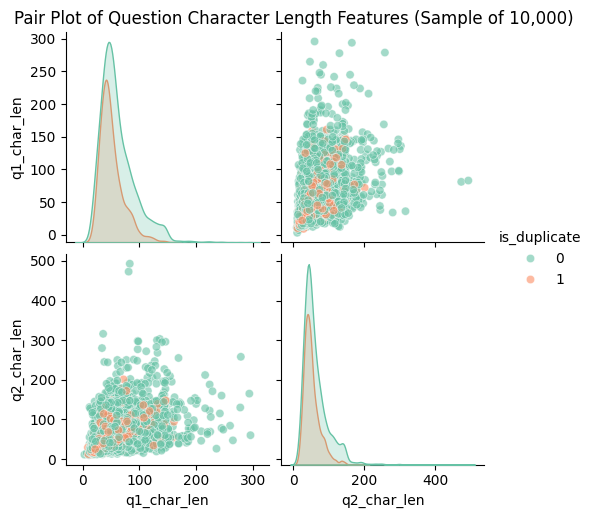

In [45]:
# Calculate length of question strings (character length) after preprocessing
df['q1_char_len'] = df['question1'].str.len()
df['q2_char_len'] = df['question2'].str.len()
df['is_duplicate'] = df['is_duplicate'].astype(str)

# Draw pair plot to compare distributions of lengths
sample_df = df[['q1_char_len', 'q2_char_len', 'is_duplicate']].sample(min(len(df), 10000), random_state=42)
sns.pairplot(sample_df, hue='is_duplicate', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle("Pair Plot of Question Character Length Features (Sample of 10,000)", y=1.02)
plt.show()


## 10. Feature Engineering: Basic Token Length & Differences
Compute token (word) counts, length differences, mean token length, and absolute minimum/maximum character boundaries using the GPU DataFrame.

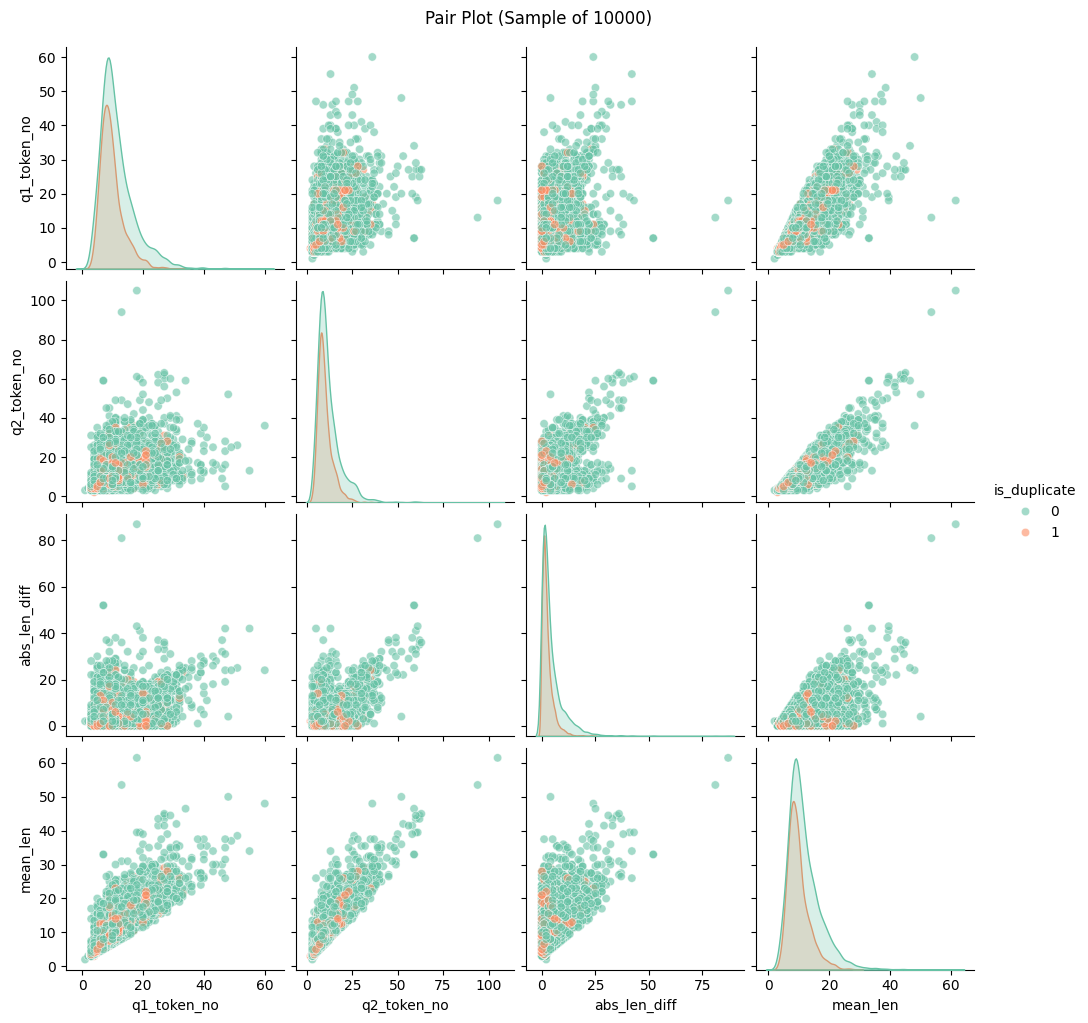

In [46]:
# Push data to cuDF GPU DataFrame or process on CPU depending on environment
if HAS_GPU:
    gdf = cudf.from_pandas(df)
    gdf['question1'] = gdf['question1'].fillna("").astype(str)
    gdf['question2'] = gdf['question2'].fillna("").astype(str)

    # Word counts
    gdf['q1_token_no'] = gdf['question1'].str.split().list.len()
    gdf['q2_token_no'] = gdf['question2'].str.split().list.len()

    # Absolute difference in token count
    gdf['abs_len_diff'] = (gdf['q1_token_no'] - gdf['q2_token_no']).abs()

    # Mean token length
    gdf['mean_len'] = (gdf['q1_token_no'] + gdf['q2_token_no']) / 2

    # Character lengths
    gdf['q1_char_len'] = gdf['question1'].str.len()
    gdf['q2_char_len'] = gdf['question2'].str.len()
    gdf['min_char_len'] = gdf[['q1_char_len', 'q2_char_len']].min(axis=1)
    gdf['max_char_len'] = gdf[['q1_char_len', 'q2_char_len']].max(axis=1)

    df = gdf.to_pandas()
else:
    df['question1'] = df['question1'].fillna("").astype(str)
    df['question2'] = df['question2'].fillna("").astype(str)

    # Word counts
    df['q1_token_no'] = df['question1'].str.split().str.len()
    df['q2_token_no'] = df['question2'].str.split().str.len()

    # Absolute difference in token count
    df['abs_len_diff'] = (df['q1_token_no'] - df['q2_token_no']).abs()

    # Mean token length
    df['mean_len'] = (df['q1_token_no'] + df['q2_token_no']) / 2

    # Character lengths
    df['q1_char_len'] = df['question1'].str.len()
    df['q2_char_len'] = df['question2'].str.len()
    df['min_char_len'] = df[['q1_char_len', 'q2_char_len']].min(axis=1)
    df['max_char_len'] = df[['q1_char_len', 'q2_char_len']].max(axis=1)

df['is_duplicate'] = df['is_duplicate'].astype(str)

sample_df = df[['q1_token_no', 'q2_token_no', 'abs_len_diff', 'mean_len', 'is_duplicate']].sample(min(len(df), 10000), random_state=42)

sns.pairplot(sample_df, hue='is_duplicate', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle("Pair Plot (Sample of 10000)", y=1.02)
plt.show()


## 11. Feature Engineering: Word Share & Stopword Analysis
Compute detailed token sharing metrics (Common words, ratios, min/max word share bounds for stopwords, first/last word matches) in parallel using multiple threads.

100%|██████████| 404287/404287 [00:39<00:00, 10147.82it/s]


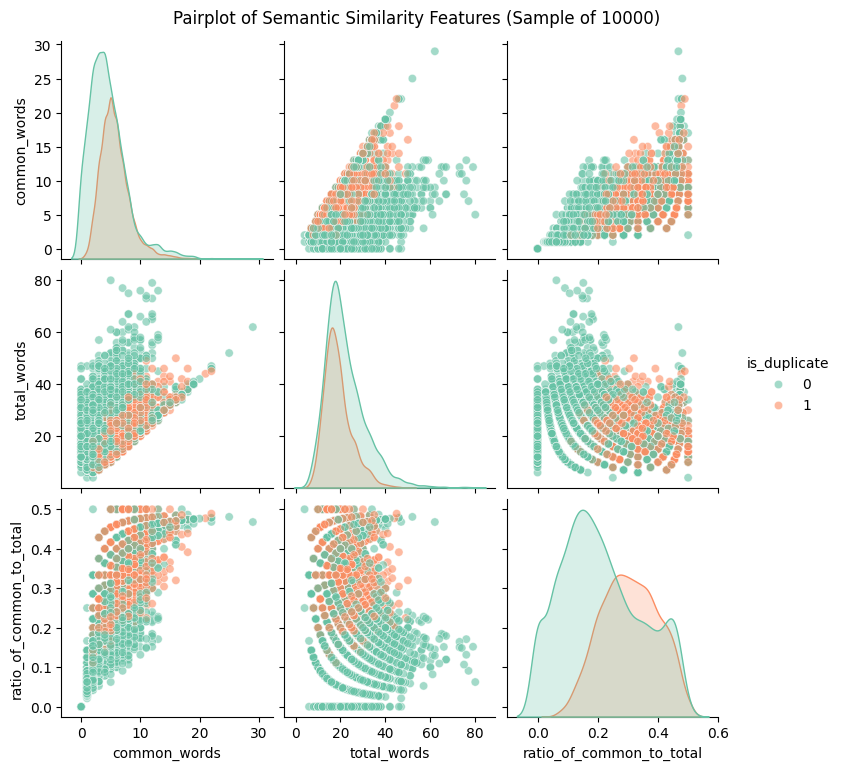

In [47]:
df['question1'] = df['question1'].fillna("").astype(str)
df['question2'] = df['question2'].fillna("").astype(str)

STOPWORDS = set(stopwords.words('english'))

def token_features(row):
    q1_words = row['question1'].split()
    q2_words = row['question2'].split()

    q1_tokens = set(q1_words)
    q2_tokens = set(q2_words)

    q1_sw = q1_tokens - STOPWORDS
    q2_sw = q2_tokens - STOPWORDS

    common        = q1_tokens & q2_tokens
    common_sw     = q1_sw & q2_sw

    total         = len(q1_tokens) + len(q2_tokens)
    n_common      = len(common)
    n_common_sw   = len(common_sw)
    min_tok       = min(len(q1_tokens), len(q2_tokens))
    max_tok       = max(len(q1_tokens), len(q2_tokens))
    min_sw        = min(len(q1_sw),     len(q2_sw))
    max_sw        = max(len(q1_sw),     len(q2_sw))

    return {
        'q1_tokens':              list(q1_tokens),
        'q2_tokens':              list(q2_tokens),
        'total_words':            total,
        'common_words':           n_common,
        'ratio_of_common_to_total': n_common / (total + 1e-5),
        'cwc_min':                n_common_sw / (min_sw  + 1e-5),
        'cwc_max':                n_common_sw / (max_sw  + 1e-5),
        'csc_min':                n_common_sw / (min_tok + 1e-5),
        'csc_max':                n_common_sw / (max_tok + 1e-5),
        'ctc_min':                n_common    / (min_tok + 1e-5),
        'ctc_max':                n_common    / (max_tok + 1e-5),
        'last_word_eq':           int(q1_words[-1] == q2_words[-1]) if q1_words and q2_words else 0,
        'first_word_eq':          int(q1_words[0]  == q2_words[0])  if q1_words and q2_words else 0,
    }

# Parallel execution across CPU cores
results_tok = Parallel(n_jobs=-1, prefer='threads')(
    delayed(token_features)(row)
    for _, row in tqdm(df.iterrows(), total=len(df))
)

tok_df = pd.DataFrame(results_tok)
df = pd.concat([df.reset_index(drop=True), tok_df.reset_index(drop=True)], axis=1)

feature_cols = [
    'common_words', 'total_words', 'ratio_of_common_to_total',
    'cwc_min', 'cwc_max', 'csc_min', 'csc_max',
    'ctc_min', 'ctc_max', 'last_word_eq', 'first_word_eq'
]

# Define your selected columns
selected_cols = ["common_words", "total_words", "ratio_of_common_to_total", "is_duplicate"]

# Ensure 'is_duplicate' is string for coloring
df['is_duplicate'] = df['is_duplicate'].astype(str)

# Sample 10000 rows from the selected columns
sample_df = df[selected_cols].sample(min(len(df), 10000), random_state=42)

# Pairplot
sns.pairplot(sample_df, hue='is_duplicate', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Semantic Similarity Features (Sample of 10000)", y=1.02)
plt.show()


## 12. Feature Engineering: Fuzzy String Matching Coefficients
Extract string distance metrics using `rapidfuzz`. We compute four ratios in parallel: standard similarity ratio, partial ratio, token sort ratio, and token set ratio.

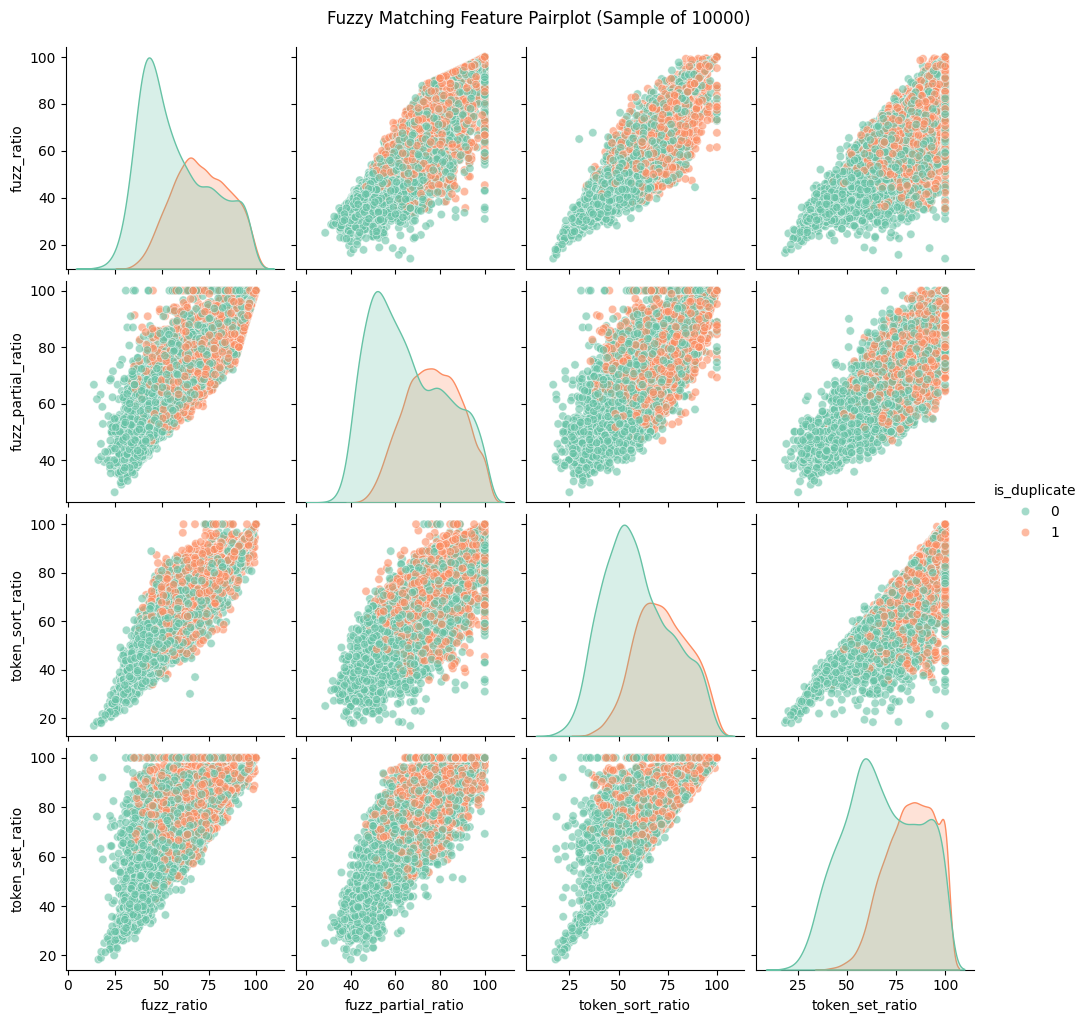

In [48]:
# Pre-calculate fuzzy matching values across CPU cores in round-robin batches
df['question1'] = df['question1'].fillna("").astype(str)
df['question2'] = df['question2'].fillna("").astype(str)

pairs = list(zip(df['question1'], df['question2']))

# Split pairs into large chunks — one chunk per worker.
# This eliminates the per-row Python call overhead that made
# ThreadPoolExecutor slow on 400k rows.
def compute_fuzzy_batch(chunk):
    out = []
    for q1, q2 in chunk:
        out.append((
            fuzz.ratio(q1, q2),
            fuzz.partial_ratio(q1, q2),
            fuzz.token_sort_ratio(q1, q2),
            fuzz.token_set_ratio(q1, q2),
        ))
    return out

n_jobs   = cpu_count()
chunks   = [pairs[i::n_jobs] for i in range(n_jobs)]   # round-robin split

# rapidfuzz releases the GIL → threads are sufficient and faster than processes
results_nested = Parallel(n_jobs=n_jobs, prefer='threads')(
    delayed(compute_fuzzy_batch)(chunk)
    for chunk in chunks
)

# Reassemble in original order (round-robin split → interleave back)
results = [None] * len(pairs)
for worker_idx, batch in enumerate(results_nested):
    for local_idx, val in enumerate(batch):
        results[worker_idx + local_idx * n_jobs] = val

df[['fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio']] = (
    np.array(results)
)

# Define fuzzy feature columns
fuzzy_cols = ['fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio', 'is_duplicate']

# Sample and prepare DataFrame
plot_df = df[fuzzy_cols].sample(min(len(df), 10000), random_state=42).copy()
plot_df['is_duplicate'] = plot_df['is_duplicate'].astype(str)

# Generate pairplot
sns.pairplot(plot_df, hue='is_duplicate', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle("Fuzzy Matching Feature Pairplot (Sample of 10000)", y=1.02)
plt.show()

## 13. Load Word2Vec Vectors
Load the pre-trained Google News Word2Vec model, which maps tokens into a dense 300-dimensional vector space.

In [49]:
# Download or load from cache the pre-trained Word2Vec embeddings
word2vec_model = api.load("word2vec-google-news-300")


## 14. Generate Sentence-Level Embeddings
Define utility methods to map text tokens to vectors and compile sentence representations by taking the mean of individual word embeddings. Executed in parallel with a multiprocessing Pool.

In [50]:
# ------------------------------------------------------------
# Embedding function
# ------------------------------------------------------------
def apply_word2vec(text):
    tokens = str(text).split()
    vectors = [
        word2vec_model[token]
        for token in tokens
        if token in word2vec_model.key_to_index
    ]

    # Return mean embedding
    if vectors:
        return np.mean(vectors, axis=0)

    # Return zero vector
    return np.zeros(word2vec_model.vector_size)

# ------------------------------------------------------------
# Threaded parallel embedding generator (safe on spawn environments like macOS)
# ------------------------------------------------------------
def parallel_embeddings(texts):
    # Using thread-based parallelism to avoid pickling overhead and macOS spawn issues
    embeddings = Parallel(n_jobs=-1, prefer='threads')(
        delayed(apply_word2vec)(t)
        for t in tqdm(texts)
    )
    return np.stack(embeddings)

# ------------------------------------------------------------
# Generate embeddings in parallel
# ------------------------------------------------------------
df = df.reset_index(drop=True)
q1_embeddings = parallel_embeddings(df['question1'])
q2_embeddings = parallel_embeddings(df['question2'])

# Vector size
vec_size = word2vec_model.vector_size

# Create embedding DataFrames
q1_embed_df = pd.DataFrame(
    q1_embeddings,
    columns=[
        f'question1_embedding_{i}'
        for i in range(vec_size)
    ]
)

q2_embed_df = pd.DataFrame(
    q2_embeddings,
    columns=[
        f'question2_embedding_{i}'
        for i in range(vec_size)
    ]
)


100%|██████████| 404287/404287 [00:34<00:00, 11592.29it/s]


## 15. Concatenate Tabular & Dense Vector Features
Align indexes and horizontally stack the basic length, semantic, fuzzy, and Word2Vec features into a unified feature matrix.

In [51]:
# Merge clean tabular variables and high-dimensional Word2Vec embeddings
# ------------------------------------------------------------
# Reset indices BEFORE concatenation
# ------------------------------------------------------------
df = df.reset_index(drop=True)

q1_embed_df = q1_embed_df.reset_index(drop=True)
q2_embed_df = q2_embed_df.reset_index(drop=True)

# ------------------------------------------------------------
# Concatenate safely
# ------------------------------------------------------------
df = pd.concat(
    [
        df,
        q1_embed_df,
        q2_embed_df
    ],
    axis=1
)

## 16. Train / Validation / Test Splitting
Separate features and target variables, and split the data into Training (70%), Validation (15%), and Test (15%) subsets with fixed random seeds.

In [52]:
# Drop metadata columns, isolate labels, and partition data into train/valid/test datasets
X = df.drop(columns=['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate', 'q1_tokens', 'q2_tokens'])
y = df['is_duplicate']
y = y.astype(int)


# First split: 70% train, 30% temp (valid + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=0)

# Second split: 50% of temp for validation, 50% for test → 15% each
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

gc.collect()

644

## 17. Feature Scaling
Standardize features by removing the mean and scaling to unit variance. The scaler is fitted on the training split only and applied to all subsets.

In [53]:
# Scale training, validation, and testing matrices using StandardScaler
scaler = StandardScaler()
train_cols, valid_cols, test_cols = X_train.columns, X_valid.columns, X_test.columns
train_idx, valid_idx, test_idx = X_train.index, X_valid.index, X_test.index

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=train_cols, index=train_idx)
X_valid = pd.DataFrame(scaler.transform(X_valid), columns=valid_cols, index=valid_idx)
X_test = pd.DataFrame(scaler.transform(X_test), columns=test_cols, index=test_idx)

## 18. Hyperparameter Optimization & Model Selection
We set up an Optuna study optimizing GBDT ensembles (LightGBM, XGBoost, CatBoost), HistGradientBoosting, and SGD models, using **F1 score** (on the validation split) as the tuning objective. After running fast-tuning trials, each model is refit and evaluated on the test split, reporting F1, Precision, Recall, AUC, Accuracy, and LogLoss; the classifier with the highest test F1 is selected as the overall winner.

In [54]:
MODEL_FACTORY = {
    "LightGBM": lambda t: LGBMClassifier(
        n_estimators=t.suggest_int("n_estimators", 200, 1000),
        learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=t.suggest_int("num_leaves", 31, 128),
        device_type="gpu" if HAS_GPU else "cpu",
        random_state=0,
        n_jobs=-1,
        verbose=-1,
    ),
    "XGBoost": lambda t: XGBClassifier(
        n_estimators=t.suggest_int("n_estimators", 200, 1000),
        learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=t.suggest_int("max_depth", 3, 8),
        tree_method="hist",
        device="cpu",
        random_state=0,
        n_jobs=-1,
    ),
    "CatBoost": lambda t: CatBoostClassifier(
        iterations=t.suggest_int("iterations", 200, 1000),
        learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
        depth=t.suggest_int("depth", 4, 8),
        task_type="GPU" if HAS_GPU else "CPU",
        random_seed=0,
        verbose=False,
    ),
    "HistGBM": lambda t: HistGradientBoostingClassifier(
        max_iter=t.suggest_int("max_iter", 100, 500),
        learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_leaf_nodes=t.suggest_int("max_leaf_nodes", 31, 128),
        random_state=0,
    ),
    "SGD": lambda t: SGDClassifier(
        loss="log_loss",
        alpha=t.suggest_float("alpha", 1e-5, 1e-1, log=True),
        penalty="l2",
        random_state=0,
        n_jobs=-1,
    ),
}

FIT_KWARGS = {
    "LightGBM": {"eval_set": [(X_valid, y_valid)]},
    "XGBoost": {"eval_set": [(X_valid, y_valid)], "verbose": False},
}

In [55]:
def instantiate_classifier(trial, clf_name):
    return MODEL_FACTORY[clf_name](trial)


def objective(trial, clf_name):
    clf = instantiate_classifier(trial, clf_name)
    clf.fit(X_train, y_train, **FIT_KWARGS.get(clf_name, {}))
    return f1_score(y_valid, clf.predict(X_valid))

In [56]:
classifiers = list(MODEL_FACTORY)

results = {}
best_overall_score = -1
best_overall_clf = None
best_overall_name = None

for clf_name in classifiers:
    print(f"Fast Tuning {clf_name}...")

    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(),
    )
    study.optimize(lambda t: objective(t, clf_name), n_trials=2)

    clf = instantiate_classifier(study.best_trial, clf_name)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test) if hasattr(clf, "predict_proba") else None

    f1 = f1_score(y_test, y_pred)

    results[clf_name] = {
        "F1": f1,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob[:, 1]) if y_prob is not None else None,
        "Acc": accuracy_score(y_test, y_pred),
        "Loss": log_loss(y_test, y_prob) if y_prob is not None else None,
        "ConfusionMatrix": confusion_matrix(y_test, y_pred).tolist(),
        "Params": study.best_params,
    }

    if f1 > best_overall_score:
        best_overall_score = f1
        best_overall_clf = clf
        best_overall_name = clf_name

[I 2026-07-02 18:16:51,724] A new study created in memory with name: no-name-7d9c3b5c-85ef-4983-9109-34edad4123e0


Fast Tuning LightGBM...


[I 2026-07-02 18:18:07,171] Trial 0 finished with value: 0.7521830907676925 and parameters: {'n_estimators': 673, 'learning_rate': 0.013365312546659168, 'num_leaves': 88}. Best is trial 0 with value: 0.7521830907676925.
[I 2026-07-02 18:18:51,085] Trial 1 finished with value: 0.7782471669013612 and parameters: {'n_estimators': 366, 'learning_rate': 0.1931372179012245, 'num_leaves': 86}. Best is trial 1 with value: 0.7782471669013612.
[I 2026-07-02 18:19:32,047] A new study created in memory with name: no-name-607e3efd-f84e-47fe-a825-58ea3dbd721b


Fast Tuning XGBoost...


[I 2026-07-02 18:26:44,174] Trial 0 finished with value: 0.7758455612210817 and parameters: {'n_estimators': 851, 'learning_rate': 0.02400793037325683, 'max_depth': 8}. Best is trial 0 with value: 0.7758455612210817.
[I 2026-07-02 18:28:45,494] Trial 1 finished with value: 0.6989734497778362 and parameters: {'n_estimators': 406, 'learning_rate': 0.01141389507623787, 'max_depth': 5}. Best is trial 0 with value: 0.7758455612210817.
[I 2026-07-02 18:35:39,150] A new study created in memory with name: no-name-4a5e6cd0-c010-4b0f-93b2-9f74a1ec3ab6


...

[I 2026-07-02 18:35:50,891] Trial 0 finished with value: 0.7404386199518588 and parameters: {'iterations': 673, 'learning_rate': 0.04739009747311337, 'depth': 7}. Best is trial 0 with value: 0.7404386199518588.
[I 2026-07-02 18:35:58,923] Trial 1 finished with value: 0.7284117921489347 and parameters: {'iterations': 251, 'learning_rate': 0.0759565221021009, 'depth': 7}. Best is trial 0 with value: 0.7404386199518588.
[I 2026-07-02 18:36:12,662] A new study created in memory with name: no-name-a9e8b61f-036f-4e49-806d-fe446954c1c3


Fast Tuning HistGBM...


[I 2026-07-02 18:37:55,202] Trial 0 finished with value: 0.7747594540165585 and parameters: {'max_iter': 281, 'learning_rate': 0.13883517468718015, 'max_leaf_nodes': 96}. Best is trial 0 with value: 0.7747594540165585.
[I 2026-07-02 18:39:55,658] Trial 1 finished with value: 0.7767311779841145 and parameters: {'max_iter': 407, 'learning_rate': 0.13106226761895184, 'max_leaf_nodes': 75}. Best is trial 1 with value: 0.7767311779841145.
[I 2026-07-02 18:41:57,667] A new study created in memory with name: no-name-507bc931-d115-4a07-948e-28782f398876


Fast Tuning SGD...


[I 2026-07-02 18:42:03,439] Trial 0 finished with value: 0.6133358926986108 and parameters: {'alpha': 0.09520664750046447}. Best is trial 0 with value: 0.6133358926986108.
[I 2026-07-02 18:42:09,248] Trial 1 finished with value: 0.6211633397724834 and parameters: {'alpha': 0.06365079893718707}. Best is trial 1 with value: 0.6211633397724834.


In [57]:
# --- Results Table ---
print("\n" + "="*140)
print(f"{'Model':<15} | {'F1':<8} | {'Precision':<10} | {'Recall':<8} | {'AUC':<8} | {'Acc':<8} | {'LogLoss':<10} | {'Best Params'}")
print("-" * 140)
for model, m in results.items():
    param_str = ", ".join([f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}" for k, v in m['Params'].items()])
    loss_val = f"{m['Loss']:.4f}" if isinstance(m['Loss'], float) else m['Loss']
    auc_val = f"{m['AUC']:.4f}" if isinstance(m['AUC'], float) else "N/A"
    print(f"{model:<15} | {m['F1']:<8.4f} | {m['Precision']:<10.4f} | {m['Recall']:<8.4f} | {auc_val:<8} | {m['Acc']:<8.4f} | {loss_val:<10} | {param_str}")

print(f"\n Winning model (by test F1): {best_overall_name} (F1 = {best_overall_score:.4f})")


Model           | F1       | Precision  | Recall   | AUC      | Acc      | LogLoss    | Best Params
--------------------------------------------------------------------------------------------------------------------------------------------
LightGBM        | 0.7776   | 0.7802     | 0.7750   | 0.9201   | 0.8372   | 0.3404     | n_estimators: 366, learning_rate: 0.1931, num_leaves: 86
XGBoost         | 0.7735   | 0.7736     | 0.7734   | 0.9175   | 0.8337   | 0.3508     | n_estimators: 851, learning_rate: 0.0240, max_depth: 8
CatBoost        | 0.7413   | 0.7387     | 0.7439   | 0.8945   | 0.8093   | 0.3911     | iterations: 673, learning_rate: 0.0474, depth: 7
HistGBM         | 0.7736   | 0.7774     | 0.7698   | 0.9183   | 0.8345   | 0.3444     | max_iter: 407, learning_rate: 0.1311, max_leaf_nodes: 75
SGD             | 0.6184   | 0.6643     | 0.5784   | 0.8243   | 0.7378   | 0.4920     | alpha: 0.0637

 Winning model (by test F1): LightGBM (F1 = 0.7776)


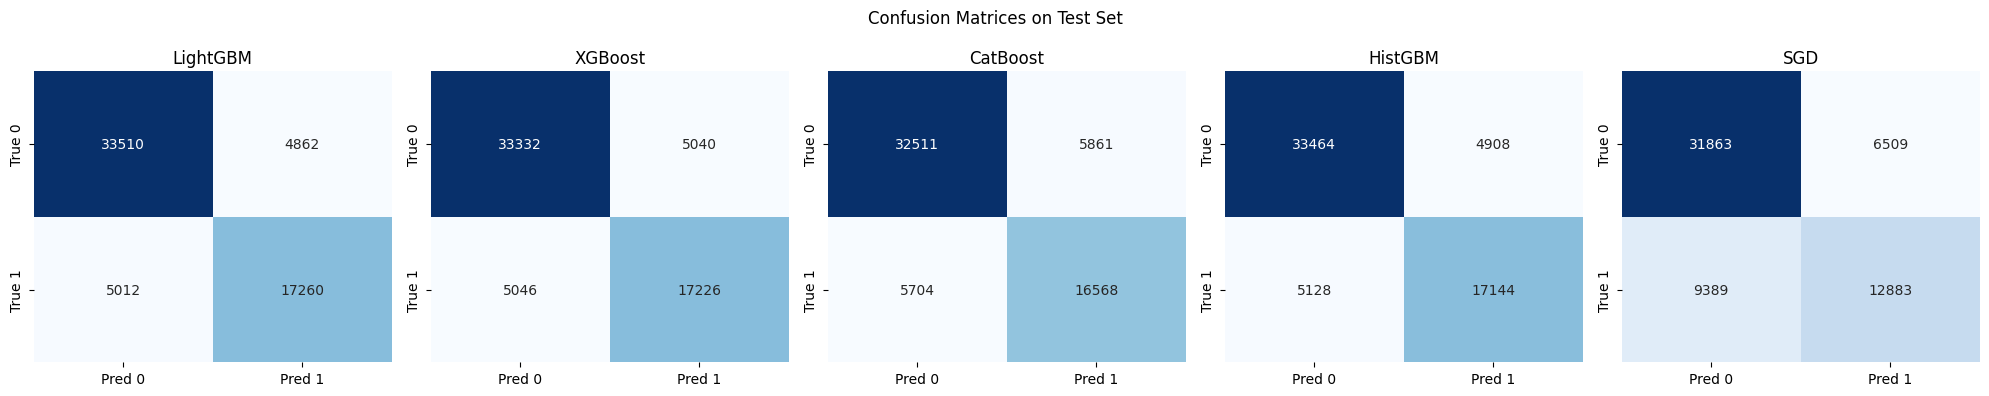

In [58]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4), squeeze=False)

for ax, (model, metrics) in zip(axes.ravel(), results.items()):
    sns.heatmap(
        metrics["ConfusionMatrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    ax.set_title(model)

plt.suptitle("Confusion Matrices on Test Set")
plt.tight_layout()
plt.show()

## 19. Classification Threshold Selection
`predict()` defaults to labeling a pair "duplicate" whenever `predict_proba()[:, 1] > 0.5`. That cutoff is arbitrary. Here we select the probability threshold that maximizes Youden's J statistic (`TPR - FPR`) on the ROC curve computed from the **validation set** for the winning model, then compare accuracy/precision/recall/F1 at the default 0.5 vs. the selected threshold on the **test set**.

Winning model: LightGBM
Best threshold: 0.3535

Threshold   Accuracy  Precision  Recall   F1
0.5000     0.8372    0.7802     0.7750   0.7776
0.3535     0.8257    0.7146     0.8750   0.7867


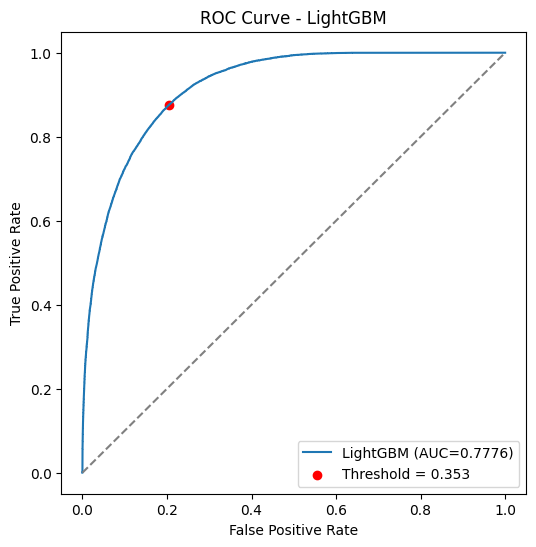

In [59]:
# Find optimal threshold (Youden's J)
valid_prob = best_overall_clf.predict_proba(X_valid)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, valid_prob)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f"Winning model: {best_overall_name}")
print(f"Best threshold: {best_threshold:.4f}")

# Evaluate on test set
test_prob = best_overall_clf.predict_proba(X_test)[:, 1]

print("\nThreshold   Accuracy  Precision  Recall   F1")
for th in [0.5, best_threshold]:
    pred = (test_prob >= th).astype(int)
    print(f"{th:<11.4f}"
          f"{accuracy_score(y_test, pred):<10.4f}"
          f"{precision_score(y_test, pred):<11.4f}"
          f"{recall_score(y_test, pred):<9.4f}"
          f"{f1_score(y_test, pred):.4f}")

# ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"{best_overall_name} (AUC={best_overall_score:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.scatter(fpr[best_idx], tpr[best_idx], color="red",
            label=f"Threshold = {best_threshold:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_overall_name}")
plt.legend()
plt.show()

## 20. Deep Learning Baseline: Siamese LSTM (PyTorch)
As a comparison to the gradient boosting ensemble above, we train a Siamese recurrent network directly on the raw preprocessed question text (no hand-engineered scalar/fuzzy features). Both questions are encoded with a **shared-weight bidirectional LSTM**, initialized from the same Word2Vec embeddings loaded earlier. The two encodings are combined (`concat`, `abs-diff`, `product`) and passed through a small MLP with a sigmoid output.

It is evaluated on the **same train/valid/test rows** used for the GBDT models (via `X_train`/`X_valid`/`X_test`'s row index, set in section 17's Feature Scaling step), so its metrics are directly comparable. Note: this model is *not* wired into the joblib/`inference.py` serialization pipeline below, since that pipeline expects the 623-dim tabular feature vector, not raw token sequences — it's an experimental baseline reported alongside the GBDT results table.

In [60]:
torch_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {torch_device}")

MAX_LEN = 40           # max tokens per question (pad/truncate)
MIN_FREQ = 4            # minimum token frequency kept in the vocabulary
EMBED_DIM = word2vec_model.vector_size  # 300 — reuse the Word2Vec model loaded earlier
HIDDEN_DIM = 256
BATCH_SIZE = 512
EPOCHS = 30
LR = 1e-3


Using device: cuda


In [61]:
# Build vocabulary from the cleaned question text (same preprocessing as the GBDT pipeline)
counter = Counter()
for text in df['question1']:
    counter.update(text.split())
for text in df['question2']:
    counter.update(text.split())

PAD_IDX, UNK_IDX = 0, 1
vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size:,}")

# Initialize the embedding matrix from the pre-trained Word2Vec vectors;
# unseen tokens get a small random vector, <PAD> stays at zero.
embedding_matrix = np.random.normal(scale=0.1, size=(vocab_size, EMBED_DIM)).astype(np.float32)
embedding_matrix[PAD_IDX] = np.zeros(EMBED_DIM, dtype=np.float32)
hits = 0
for word, idx in vocab.items():
    if word in word2vec_model.key_to_index:
        embedding_matrix[idx] = word2vec_model[word]
        hits += 1
print(f"Word2Vec coverage: {hits:,}/{vocab_size:,} ({hits / vocab_size:.1%})")

def encode(text: str) -> list:
    ids = [vocab.get(tok, UNK_IDX) for tok in text.split()[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids


Vocabulary size: 36,463
Word2Vec coverage: 27,626/36,463 (75.8%)


In [62]:
class QuestionPairDataset(Dataset):
    def __init__(self, indices):
        self.q1 = df.loc[indices, 'question1'].tolist()
        self.q2 = df.loc[indices, 'question2'].tolist()
        self.labels = df.loc[indices, 'is_duplicate'].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        q1_ids = torch.tensor(encode(self.q1[i]), dtype=torch.long)
        q2_ids = torch.tensor(encode(self.q2[i]), dtype=torch.long)
        label = torch.tensor(self.labels[i], dtype=torch.float32)
        return q1_ids, q2_ids, label

# Reuse the exact same rows as the GBDT train/valid/test split.
# X_train/X_valid/X_test already carry that split's row index (set in section 17's
# Feature Scaling step), so we read it off them directly.
train_ds = QuestionPairDataset(X_train.index)
valid_ds = QuestionPairDataset(X_valid.index)
test_ds  = QuestionPairDataset(X_test.index)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


In [63]:
class SiameseEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=PAD_IDX
        )
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        combined_dim = hidden_dim * 2 * 4  # [h1, h2, |h1-h2|, h1*h2], each hidden_dim*2 (bidirectional)
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def encode(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        # h_n: (num_directions, batch, hidden_dim) -> concat forward/backward
        return torch.cat([h_n[0], h_n[1]], dim=1)

    def forward(self, q1, q2):
        h1 = self.encode(q1)
        h2 = self.encode(q2)
        combined = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=1)
        return self.classifier(combined).squeeze(1)

siamese_model = SiameseEncoder(vocab_size, EMBED_DIM, HIDDEN_DIM, embedding_matrix).to(torch_device)
optimizer = torch.optim.Adam(siamese_model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()


In [64]:
def evaluate(loader):
    siamese_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for q1, q2, labels in loader:
            q1, q2 = q1.to(torch_device), q2.to(torch_device)
            logits = siamese_model(q1, q2)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_probs)

def metrics_report(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'F1': f1_score(labels, preds),
        'Precision': precision_score(labels, preds, zero_division=0),
        'Recall': recall_score(labels, preds),
        'AUC': roc_auc_score(labels, probs),
        'Acc': accuracy_score(labels, preds),
        'Loss': log_loss(labels, probs),
    }

best_valid_f1 = -1
best_state = None
epoch_history = []

for epoch in range(1, EPOCHS + 1):
    siamese_model.train()
    total_loss = 0.0
    for q1, q2, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        q1, q2, labels = q1.to(torch_device), q2.to(torch_device), labels.to(torch_device)
        optimizer.zero_grad()
        logits = siamese_model(q1, q2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)

    train_loss = total_loss / len(train_ds)
    valid_labels, valid_probs = evaluate(valid_loader)
    valid_metrics = metrics_report(valid_labels, valid_probs)
    valid_metrics['train_loss'] = train_loss
    epoch_history.append(valid_metrics)

    print(
        f"Epoch {epoch}: train_loss={train_loss:.4f} | "
        f"valid_F1={valid_metrics['F1']:.4f} | "
        f"valid_Precision={valid_metrics['Precision']:.4f} | "
        f"valid_Recall={valid_metrics['Recall']:.4f} | "
        f"valid_AUC={valid_metrics['AUC']:.4f} | "
        f"valid_Acc={valid_metrics['Acc']:.4f} | "
        f"valid_LogLoss={valid_metrics['Loss']:.4f}"
    )

    if valid_metrics['F1'] > best_valid_f1:
        best_valid_f1 = valid_metrics['F1']
        best_state = {k: v.cpu().clone() for k, v in siamese_model.state_dict().items()}

siamese_model.load_state_dict(best_state)
siamese_model.to(torch_device)
print(f"\nBest validation F1: {best_valid_f1:.4f}")

# Per-epoch metrics table
print("\n" + "="*100)
print(f"{'Epoch':<6} | {'TrainLoss':<10} | {'F1':<8} | {'Precision':<10} | {'Recall':<8} | {'AUC':<8} | {'Acc':<8} | {'LogLoss':<10}")
print("-" * 100)
for i, m in enumerate(epoch_history, start=1):
    print(f"{i:<6} | {m['train_loss']:<10.4f} | {m['F1']:<8.4f} | {m['Precision']:<10.4f} | {m['Recall']:<8.4f} | {m['AUC']:<8.4f} | {m['Acc']:<8.4f} | {m['Loss']:<10.4f}")


Epoch 1/30: 100%|██████████| 553/553 [00:14<00:00, 37.33it/s]


Epoch 1: train_loss=0.4543 | valid_F1=0.7462 | valid_Precision=0.7709 | valid_Recall=0.7231 | valid_AUC=0.8953 | valid_Acc=0.8186 | valid_LogLoss=0.3917


Epoch 2/30: 100%|██████████| 553/553 [00:14<00:00, 37.75it/s]


Epoch 2: train_loss=0.3330 | valid_F1=0.7854 | valid_Precision=0.7710 | valid_Recall=0.8004 | valid_AUC=0.9138 | valid_Acc=0.8387 | valid_LogLoss=0.3598


Epoch 3/30: 100%|██████████| 553/553 [00:16<00:00, 34.32it/s]


...

Epoch 28: train_loss=0.0086 | valid_F1=0.7983 | valid_Precision=0.7759 | valid_Recall=0.8221 | valid_AUC=0.9163 | valid_Acc=0.8468 | valid_LogLoss=1.1660


Epoch 29/30: 100%|██████████| 553/553 [00:15<00:00, 36.41it/s]


Epoch 29: train_loss=0.0080 | valid_F1=0.7956 | valid_Precision=0.8021 | valid_Recall=0.7892 | valid_AUC=0.9164 | valid_Acc=0.8504 | valid_LogLoss=1.1500


Epoch 30/30: 100%|██████████| 553/553 [00:16<00:00, 33.43it/s]


Epoch 30: train_loss=0.0074 | valid_F1=0.7937 | valid_Precision=0.8028 | valid_Recall=0.7849 | valid_AUC=0.9172 | valid_Acc=0.8495 | valid_LogLoss=1.1214

Best validation F1: 0.7998

Epoch  | TrainLoss  | F1       | Precision  | Recall   | AUC      | Acc      | LogLoss   
----------------------------------------------------------------------------------------------------
1      | 0.4543     | 0.7462   | 0.7709     | 0.7231   | 0.8953   | 0.8186   | 0.3917    
2      | 0.3330     | 0.7854   | 0.7710     | 0.8004   | 0.9138   | 0.8387   | 0.3598    
3      | 0.2546     | 0.7975   | 0.7662     | 0.8315   | 0.9190   | 0.8443   | 0.3624    
4      | 0.1968     | 0.7964   | 0.7954     | 0.7975   | 0.9191   | 0.8496   | 0.3936    
5      | 0.1497     | 0.7985   | 0.7908     | 0.8063   | 0.9177   | 0.8499   | 0.4426    
6      | 0.1144     | 0.7979   | 0.7778     | 0.8189   | 0.9150   | 0.8469   | 0.5353    
7      | 0.0867     | 0.7974   | 0.7718     | 0.8247   | 0.9126   | 0.8454   | 0.6127 

In [65]:
test_labels, test_probs = evaluate(test_loader)
test_preds = (test_probs >= 0.5).astype(int)

siamese_f1 = f1_score(test_labels, test_preds)
siamese_precision = precision_score(test_labels, test_preds, zero_division=0)
siamese_recall = recall_score(test_labels, test_preds)
siamese_auc = roc_auc_score(test_labels, test_probs)
siamese_acc = accuracy_score(test_labels, test_preds)
siamese_loss = log_loss(test_labels, test_probs)
siamese_cm = confusion_matrix(test_labels, test_preds)

# Append to the same results dict used for the GBDT comparison table
results['SiameseLSTM'] = {
    'F1': siamese_f1,
    'Precision': siamese_precision,
    'Recall': siamese_recall,
    'AUC': siamese_auc,
    'Acc': siamese_acc,
    'Loss': siamese_loss,
    'ConfusionMatrix': siamese_cm.tolist(),
    'Params': {'hidden_dim': HIDDEN_DIM, 'max_len': MAX_LEN, 'epochs': EPOCHS, 'lr': LR},
}

print(
    f"Siamese LSTM \u2014 Test F1: {siamese_f1:.4f} | Precision: {siamese_precision:.4f} | "
    f"Recall: {siamese_recall:.4f} | AUC: {siamese_auc:.4f} | Acc: {siamese_acc:.4f} | LogLoss: {siamese_loss:.4f}"
)
print("Confusion matrix:")
print(siamese_cm)

print("\n" + "="*140)
print(f"{'Model':<15} | {'F1':<8} | {'Precision':<10} | {'Recall':<8} | {'AUC':<8} | {'Acc':<8} | {'LogLoss':<10}")
print("-" * 140)
for name, m in results.items():
    print(f"{name:<15} | {m['F1']:<8.4f} | {m['Precision']:<10.4f} | {m['Recall']:<8.4f} | {m['AUC']:<8.4f} | {m['Acc']:<8.4f} | {m['Loss']:<10.4f}")

# The GBDT loop (section 18) only ever compares among the 5 statistical models, so
# best_overall_name/best_overall_clf can never become "SiameseLSTM" even if it truly
# has the highest F1. Recompute the TRUE cross-architecture winner across all 6 models here.
overall_best_name = max(results, key=lambda k: results[k]['F1'])
overall_best_f1 = results[overall_best_name]['F1']

if overall_best_name == 'SiameseLSTM':
    print(
        f"\n\U0001f3c6 TRUE overall winner (by test F1, across all 6 models): SiameseLSTM "
        f"(F1 = {overall_best_f1:.4f}) — this BEATS the best statistical model "
        f"({best_overall_name}, F1 = {best_overall_score:.4f}).\n"
        "Note: the serialization step below still deploys the best *statistical* model, "
        "since inference.py's pipeline expects the 623-dim tabular feature vector, not raw "
        "token sequences. The Siamese model's weights and vocabulary are saved separately "
        "so it can still be deployed through its own inference path if desired."
    )
else:
    print(
        f"\n\U0001f3c6 TRUE overall winner (by test F1, across all 6 models): {overall_best_name} "
        f"(F1 = {overall_best_f1:.4f}) — the statistical ensemble beat the Siamese LSTM "
        f"(F1 = {siamese_f1:.4f})."
    )

Siamese LSTM — Test F1: 0.7986 | Precision: 0.7919 | Recall: 0.8053 | AUC: 0.9181 | Acc: 0.8508 | LogLoss: 1.0253
Confusion matrix:
[[33659  4713]
 [ 4336 17936]]

Model           | F1       | Precision  | Recall   | AUC      | Acc      | LogLoss   
--------------------------------------------------------------------------------------------------------------------------------------------
LightGBM        | 0.7776   | 0.7802     | 0.7750   | 0.9201   | 0.8372   | 0.3404    
XGBoost         | 0.7735   | 0.7736     | 0.7734   | 0.9175   | 0.8337   | 0.3508    
CatBoost        | 0.7413   | 0.7387     | 0.7439   | 0.8945   | 0.8093   | 0.3911    
HistGBM         | 0.7736   | 0.7774     | 0.7698   | 0.9183   | 0.8345   | 0.3444    
SGD             | 0.6184   | 0.6643     | 0.5784   | 0.8243   | 0.7378   | 0.4920    
SiameseLSTM     | 0.7986   | 0.7919     | 0.8053   | 0.9181   | 0.8508   | 1.0253    

🏆 TRUE overall winner (by test F1, across all 6 models): SiameseLSTM (F1 = 0.7986) — this BE

## 21. Winning Model Serialization
Export the best *statistical* classifier (the one `inference.py` deploys) and the performance metadata logs as files. If the Siamese LSTM turns out to be the true best model by F1 across all 6 candidates, its weights and vocabulary are saved separately, since it needs its own raw-text inference path rather than the tabular-feature pipeline below.

In [66]:
# Serialize the winning statistical model (inference.py's tabular pipeline only supports
# these) and, separately, the Siamese LSTM if it's the TRUE overall winner by F1.

# 1. Save the best statistical model object — this is what inference.py loads and deploys.
joblib.dump(best_overall_clf, 'winning_xgb_model.joblib', compress=3)

# 2. If the Siamese LSTM actually beat every statistical model, save its artifacts too
#    (weights + vocabulary), since it can't share the tabular-feature joblib pipeline.
siamese_is_true_winner = overall_best_name == 'SiameseLSTM'
if siamese_is_true_winner:
    torch.save(siamese_model.state_dict(), 'siamese_model.pt')
    with open('siamese_vocab.json', 'w') as f:
        json.dump({'vocab': vocab, 'max_len': MAX_LEN, 'hidden_dim': HIDDEN_DIM}, f)
    print("Saved Siamese LSTM weights to 'siamese_model.pt' and vocabulary to 'siamese_vocab.json' "
          "(it is the true best model by F1, but requires its own raw-text inference path).")

# 3. Save the results metadata (The "stats"), including the tuned decision threshold and the
#    TRUE cross-architecture winner (which may differ from best_overall_name/best_overall_clf,
#    the latter being restricted to the statistical models actually deployed via joblib).
with open('tuning_results.json', 'w') as f:
    json.dump({
        'results': results,
        'best_statistical_name': best_overall_name,
        'best_statistical_f1': best_overall_score,
        'overall_best_name': overall_best_name,
        'overall_best_f1': overall_best_f1,
        'best_threshold': float(best_threshold),
    }, f, indent=4)

print(f"✅ Model and metadata saved successfully.")
print(f"   Deployed (joblib/inference.py): {best_overall_name} (F1={best_overall_score:.4f}, threshold={best_threshold:.4f})")
print(f"   True best by F1 across all models: {overall_best_name} (F1={overall_best_f1:.4f})")

Saved Siamese LSTM weights to 'siamese_model.pt' and vocabulary to 'siamese_vocab.json' (it is the true best model by F1, but requires its own raw-text inference path).
✅ Model and metadata saved successfully.
   Deployed (joblib/inference.py): LightGBM (F1=0.7776, threshold=0.3535)
   True best by F1 across all models: SiameseLSTM (F1=0.7986)


## 22. Feature Scaler Serialization
Save the fitted `StandardScaler` to disk. The inference module will load this scaler to process incoming query pairs in production.

In [67]:
# Save fitted standard scaling instance to disk

# Assuming your scaler object is named 'scaler'
joblib.dump(scaler, 'scaler.joblib', compress=3)

# Also ensure the overall best model is saved with the exact name the script expects
joblib.dump(best_overall_clf, 'winning_xgb_model.joblib', compress=3)


['winning_xgb_model.joblib']

## 23. Standard Inference Pipeline (`inference.py` Code Base)
This cell contains the standalone CPU-compatible preprocessing and classification code that can be deployed to web or API servers.

In [68]:
"""
Inference script for Quora Duplicate Question Detection.
Runs the full preprocessing + feature engineering pipeline on two input sentences.

Saved artifacts required:
    winning_xgb_model.joblib   — trained XGBoost model
    scaler.joblib              — fitted StandardScaler
    word2vec-google-news-300   — loaded via gensim.downloader (cached after first run)

Usage:
    python inference.py
    or import predict() directly.
"""

import json
import re
import string
import warnings

import joblib
import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from nltk.corpus import stopwords
import nltk
import gensim.downloader as api

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)

# ---------------------------------------------------------------------------
# Contraction map (same as notebook)
# ---------------------------------------------------------------------------
CONTRACTIONS = {
    "ain't": "am not", "aren't": "are not", "can't": "can not",
    "can't've": "can not have", "'cause": "because",
    "could've": "could have", "couldn't": "could not",
    "couldn't've": "could not have", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will",
    "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will",
    "how's": "how is", "i'd": "i would", "i'd've": "i would have",
    "i'll": "i will", "i'll've": "i will have", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will",
    "it'll've": "it will have", "it's": "it is", "let's": "let us",
    "ma'am": "madam", "mayn't": "may not", "might've": "might have",
    "mightn't": "might not", "mightn't've": "might not have",
    "must've": "must have", "mustn't": "must not",
    "mustn't've": "must not have", "needn't": "need not",
    "needn't've": "need not have", "o'clock": "of the clock",
    "oughtn't": "ought not", "oughtn't've": "ought not have",
    "shan't": "shall not", "sha'n't": "shall not",
    "shan't've": "shall not have", "she'd": "she would",
    "she'd've": "she would have", "she'll": "she will",
    "she'll've": "she will have", "she's": "she is",
    "should've": "should have", "shouldn't": "should not",
    "shouldn't've": "should not have", "so've": "so have",
    "so's": "so as", "that'd": "that would",
    "that'd've": "that would have", "that's": "that is",
    "there'd": "there would", "there'd've": "there would have",
    "there's": "there is", "they'd": "they would",
    "they'd've": "they would have", "they'll": "they will",
    "they'll've": "they will have", "they're": "they are",
    "they've": "they have", "to've": "to have", "wasn't": "was not",
    "we'd": "we would", "we'd've": "we would have", "we'll": "we will",
    "we'll've": "we will have", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will",
    "what'll've": "what will have", "what're": "what are",
    "what's": "what is", "what've": "what have", "when's": "when is",
    "when've": "when have", "where'd": "where did",
    "where's": "where is", "where've": "where have",
    "who'll": "who will", "who'll've": "who will have",
    "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not",
    "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "wouldn't've": "would not have",
    "y'all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are",
    "y'all've": "you all have", "you'd": "you would",
    "you'd've": "you would have", "you'll": "you will",
    "you'll've": "you will have", "you're": "you are",
    "you've": "you have",
}

SYMBOL_REPLACEMENTS = {
    "%": " percent ",
    "$": " dollar ",
    "₹": " rupee ",
    "€": " euro ",
    "@": " at ",
    "[math]": "",
}

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)

PUNCTUATION_PATTERN = re.compile("[" + re.escape(string.punctuation) + "]")
STOPWORDS = set(stopwords.words("english"))


# ---------------------------------------------------------------------------
# Step 1 — Preprocessing (CPU mirror of the GPU notebook pipeline)
# ---------------------------------------------------------------------------
def preprocess(text: str) -> str:
    text = str(text).lower().strip()
    text = EMOJI_PATTERN.sub("", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    for old, new in SYMBOL_REPLACEMENTS.items():
        text = text.replace(old, new)
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    text = PUNCTUATION_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------------------------
# Step 2 — Length features
# ---------------------------------------------------------------------------
def length_features(q1: str, q2: str) -> dict:
    q1_char = len(q1)
    q2_char = len(q2)
    q1_tok  = len(q1.split())
    q2_tok  = len(q2.split())
    return {
        "q1_char_len":  q1_char,
        "q2_char_len":  q2_char,
        "q1_token_no":  q1_tok,
        "q2_token_no":  q2_tok,
        "abs_len_diff": abs(q1_tok - q2_tok),
        "mean_len":     (q1_tok + q2_tok) / 2,
        "min_char_len": min(q1_char, q2_char),
        "max_char_len": max(q1_char, q2_char),
    }


# ---------------------------------------------------------------------------
# Step 3 — Token features
# ---------------------------------------------------------------------------
def token_features(q1: str, q2: str) -> dict:
    q1_words = q1.split()
    q2_words = q2.split()

    q1_tokens = set(q1_words)
    q2_tokens = set(q2_words)

    q1_sw = q1_tokens - STOPWORDS
    q2_sw = q2_tokens - STOPWORDS

    common      = q1_tokens & q2_tokens
    common_sw   = q1_sw & q2_sw

    total       = len(q1_tokens) + len(q2_tokens)
    n_common    = len(common)
    n_common_sw = len(common_sw)
    min_tok     = min(len(q1_tokens), len(q2_tokens))
    max_tok     = max(len(q1_tokens), len(q2_tokens))
    min_sw      = min(len(q1_sw), len(q2_sw))
    max_sw      = max(len(q1_sw), len(q2_sw))

    return {
        "total_words":              total,
        "common_words":             n_common,
        "ratio_of_common_to_total": n_common / (total + 1e-5),
        "cwc_min":   n_common_sw / (min_sw  + 1e-5),
        "cwc_max":   n_common_sw / (max_sw  + 1e-5),
        "csc_min":   n_common_sw / (min_tok + 1e-5),
        "csc_max":   n_common_sw / (max_tok + 1e-5),
        "ctc_min":   n_common    / (min_tok + 1e-5),
        "ctc_max":   n_common    / (max_tok + 1e-5),
        "last_word_eq":  int(q1_words[-1] == q2_words[-1]) if q1_words and q2_words else 0,
        "first_word_eq": int(q1_words[0]  == q2_words[0])  if q1_words and q2_words else 0,
    }


# ---------------------------------------------------------------------------
# Step 4 — Fuzzy features
# ---------------------------------------------------------------------------
def fuzzy_features(q1: str, q2: str) -> dict:
    return {
        "fuzz_ratio":        fuzz.ratio(q1, q2),
        "fuzz_partial_ratio": fuzz.partial_ratio(q1, q2),
        "token_sort_ratio":  fuzz.token_sort_ratio(q1, q2),
        "token_set_ratio":   fuzz.token_set_ratio(q1, q2),
    }


# ---------------------------------------------------------------------------
# Step 5 — Word2Vec embedding (mean of token vectors)
# ---------------------------------------------------------------------------
def embed(text: str, w2v_model) -> np.ndarray:
    tokens  = text.split()
    vectors = [w2v_model[t] for t in tokens if t in w2v_model.key_to_index]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(w2v_model.vector_size)


# ---------------------------------------------------------------------------
# Full feature vector (must match training column order)
# ---------------------------------------------------------------------------
SCALAR_COLUMNS = [
    "q1_char_len", "q2_char_len",
    "q1_token_no", "q2_token_no",
    "abs_len_diff", "mean_len",
    "min_char_len", "max_char_len",
    "total_words", "common_words", "ratio_of_common_to_total",
    "cwc_min", "cwc_max", "csc_min", "csc_max",
    "ctc_min", "ctc_max",
    "last_word_eq", "first_word_eq",
    "fuzz_ratio", "fuzz_partial_ratio",
    "token_sort_ratio", "token_set_ratio",
]
FEATURE_COLUMNS = (
    SCALAR_COLUMNS
    + [f"question1_embedding_{i}" for i in range(300)]
    + [f"question2_embedding_{i}" for i in range(300)]
)


def build_feature_vector(q1_clean: str, q2_clean: str, w2v_model) -> pd.DataFrame:
    feats = {}
    feats.update(length_features(q1_clean, q2_clean))
    feats.update(token_features(q1_clean, q2_clean))
    feats.update(fuzzy_features(q1_clean, q2_clean))

    scalar_vec = np.array([feats[c] for c in SCALAR_COLUMNS], dtype=np.float64)

    q1_embed = embed(q1_clean, w2v_model)   # shape (300,)
    q2_embed = embed(q2_clean, w2v_model)   # shape (300,)

    full_vec = np.concatenate([scalar_vec, q1_embed, q2_embed])  # shape (623,)
    return pd.DataFrame([full_vec], columns=FEATURE_COLUMNS)


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------
def load_artifacts(
    model_path: str = "winning_xgb_model.joblib",
    scaler_path: str = "scaler.joblib",
    w2v_model_name: str = "word2vec-google-news-300",
    results_path: str = "tuning_results.json",
):
    print("Loading model...")
    try:
        model = joblib.load(model_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Model file '{model_path}' not found.\n"
            "Save it from your notebook with:\n"
            "  joblib.dump(best_clf, 'winning_xgb_model.joblib', compress=3)"
        )

    print("Loading scaler...")
    try:
        scaler = joblib.load(scaler_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Scaler file '{scaler_path}' not found.\n"
            "Save it from your notebook with:\n"
            "  joblib.dump(scaler, 'scaler.joblib', compress=3)"
        )

    # The decision threshold tuned via Youden's J on the validation set
    # (see notebook section 19). Falls back to the default 0.5 cutoff if
    # tuning_results.json wasn't saved alongside the model.
    threshold = 0.5
    try:
        with open(results_path) as f:
            threshold = float(json.load(f).get("best_threshold", 0.5))
        print(f"Loaded tuned decision threshold: {threshold:.4f}")
    except FileNotFoundError:
        print(f"'{results_path}' not found — using default threshold 0.5")

    print("Loading Word2Vec (uses local cache after first download)...")
    w2v = api.load(w2v_model_name)
    print("All artifacts loaded.")
    return model, scaler, w2v, threshold


def predict(
    sentence1: str,
    sentence2: str,
    model,
    scaler,
    w2v_model,
    threshold: float = 0.5,
) -> dict:
    q1 = preprocess(sentence1)
    q2 = preprocess(sentence2)

    x = build_feature_vector(q1, q2, w2v_model)
    x_scaled = pd.DataFrame(scaler.transform(x), columns=x.columns)

    prob = float(model.predict_proba(x_scaled)[0][1])
    label = prob >= threshold

    return {
        "is_duplicate": bool(label),
        "duplicate_probability": round(prob, 4),
        "threshold_used": threshold,
        "cleaned_q1": q1,
        "cleaned_q2": q2,
    }


# ---------------------------------------------------------------------------
# CLI demo
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    model, scaler, w2v, threshold = load_artifacts()

    pairs = [
        (
            "What is the step by step guide to invest in share market in india?",
            "What is the step by step guide to invest in share market?",
        ),
        (
            "Do you believe there is life after death?",
            "Is it true that there is life after death?"
        )
    ]

    print("\n" + "=" * 70)
    for q1, q2 in pairs:
        result = predict(q1, q2, model, scaler, w2v, threshold=threshold)
        print(f"Q1: {q1}")
        print(f"Q2: {q2}")
        print(f"Duplicate: {result['is_duplicate']}  |  Probability: {result['duplicate_probability']:.4f}")
        print("-" * 70)


Loading model...
Loading scaler...
Loaded tuned decision threshold: 0.3535
Loading Word2Vec (uses local cache after first download)...
All artifacts loaded.

Q1: What is the step by step guide to invest in share market in india?
Q2: What is the step by step guide to invest in share market?
Duplicate: False  |  Probability: 0.2601
----------------------------------------------------------------------
Q1: Do you believe there is life after death?
Q2: Is it true that there is life after death?
Duplicate: True  |  Probability: 0.6393
----------------------------------------------------------------------


## 24. Siamese LSTM Inference Pipeline (`lstm_inference.py` Code Base)
This is only relevant if section 20's `overall_best_name` turned out to be `'SiameseLSTM'` (see section 21's serialization output). It is a standalone, self-contained script — separate from section 23's `inference.py` — since the LSTM consumes raw tokenized text, not the 623-dim tabular feature vector, and therefore needs its own preprocessing → tokenization → model path.

Required saved artifacts (written by section 21, only if the LSTM was the true winner):
- `siamese_model.pt` — trained `SiameseEncoder` weights
- `siamese_vocab.json` — vocabulary + `max_len`/`hidden_dim` config used at training time

In [69]:
"""
Inference script for the Siamese LSTM duplicate-question detector.
Use this instead of inference.py only if the LSTM was the true best model by F1
(see section 20/21's overall_best_name).

Saved artifacts required:
    siamese_model.pt     — trained SiameseEncoder state_dict
    siamese_vocab.json    — vocabulary + max_len/hidden_dim config

Usage:
    python lstm_inference.py
    or import predict() directly.
"""

import json
import re
import string

import torch
import torch.nn as nn

# ---------------------------------------------------------------------------
# Text cleaning — must exactly mirror the notebook's preprocess_gpu (section 8),
# since that's what question1/question2 were cleaned with before training.
# ---------------------------------------------------------------------------
CONTRACTIONS = {
    "ain't": "am not", "aren't": "are not", "can't": "can not",
    "can't've": "can not have", "'cause": "because",
    "could've": "could have", "couldn't": "could not",
    "couldn't've": "could not have", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will",
    "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will",
    "how's": "how is", "i'd": "i would", "i'd've": "i would have",
    "i'll": "i will", "i'll've": "i will have", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'd've": "it would have", "it'll": "it will",
    "it'll've": "it will have", "it's": "it is", "let's": "let us",
    "ma'am": "madam", "mayn't": "may not", "might've": "might have",
    "mightn't": "might not", "mightn't've": "might not have",
    "must've": "must have", "mustn't": "must not",
    "mustn't've": "must not have", "needn't": "need not",
    "needn't've": "need not have", "o'clock": "of the clock",
    "oughtn't": "ought not", "oughtn't've": "ought not have",
    "shan't": "shall not", "sha'n't": "shall not",
    "shan't've": "shall not have", "she'd": "she would",
    "she'd've": "she would have", "she'll": "she will",
    "she'll've": "she will have", "she's": "she is",
    "should've": "should have", "shouldn't": "should not",
    "shouldn't've": "should not have", "so've": "so have",
    "so's": "so as", "that'd": "that would",
    "that'd've": "that would have", "that's": "that is",
    "there'd": "there would", "there'd've": "there would have",
    "there's": "there is", "they'd": "they would",
    "they'd've": "they would have", "they'll": "they will",
    "they'll've": "they will have", "they're": "they are",
    "they've": "they have", "to've": "to have", "wasn't": "was not",
    "we'd": "we would", "we'd've": "we would have", "we'll": "we will",
    "we'll've": "we will have", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will",
    "what'll've": "what will have", "what're": "what are",
    "what's": "what is", "what've": "what have", "when's": "when is",
    "when've": "when have", "where'd": "where did",
    "where's": "where is", "where've": "where have",
    "who'll": "who will", "who'll've": "who will have",
    "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not",
    "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "wouldn't've": "would not have",
    "y'all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are",
    "y'all've": "you all have", "you'd": "you would",
    "you'd've": "you would have", "you'll": "you will",
    "you'll've": "you will have", "you're": "you are",
    "you've": "you have",
}

SYMBOL_REPLACEMENTS = {
    "%": " percent ",
    "$": " dollar ",
    "₹": " rupee ",
    "€": " euro ",
    "@": " at ",
    "[math]": "",
}

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)

PUNCTUATION_PATTERN = re.compile("[" + re.escape(string.punctuation) + "]")


def preprocess(text: str) -> str:
    text = str(text).lower().strip()
    text = EMOJI_PATTERN.sub("", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    for old, new in SYMBOL_REPLACEMENTS.items():
        text = text.replace(old, new)
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    text = PUNCTUATION_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------------------------
# Model architecture — must exactly match SiameseEncoder from section 20's
# training cell, since we're loading its state_dict into this definition.
# ---------------------------------------------------------------------------
class SiameseEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.as_tensor(embedding_matrix, dtype=torch.float32), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        combined_dim = hidden_dim * 2 * 4
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def encode(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        return torch.cat([h_n[0], h_n[1]], dim=1)

    def forward(self, q1, q2):
        h1 = self.encode(q1)
        h2 = self.encode(q2)
        combined = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=1)
        return self.classifier(combined).squeeze(1)


def encode_tokens(text: str, vocab: dict, max_len: int) -> list:
    unk_idx = vocab['<UNK>']
    pad_idx = vocab['<PAD>']
    ids = [vocab.get(tok, unk_idx) for tok in text.split()[:max_len]]
    ids += [pad_idx] * (max_len - len(ids))
    return ids


def load_artifacts(
    model_path: str = 'siamese_model.pt',
    vocab_path: str = 'siamese_vocab.json',
    embed_dim: int = 300,
):
    print("Loading vocabulary and config...")
    try:
        with open(vocab_path) as f:
            meta = json.load(f)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{vocab_path}' not found. This file is only written by the notebook's "
            "Winning Model Serialization step if the Siamese LSTM was the true best model."
        )
    vocab = meta['vocab']
    max_len = meta['max_len']
    hidden_dim = meta['hidden_dim']

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print("Loading model weights...")
    try:
        state_dict = torch.load(model_path, map_location=device)
    except FileNotFoundError:
        raise FileNotFoundError(f"'{model_path}' not found alongside '{vocab_path}'.")

    # The embedding matrix values don't matter here — load_state_dict overwrites them;
    # we just need a correctly-shaped placeholder to construct the module.
    placeholder_embeddings = torch.zeros(len(vocab), embed_dim)
    model = SiameseEncoder(len(vocab), embed_dim, hidden_dim, placeholder_embeddings)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    print("All artifacts loaded.")
    return model, vocab, max_len, device


def predict(
    sentence1: str,
    sentence2: str,
    model,
    vocab: dict,
    max_len: int,
    device,
    threshold: float = 0.5,
) -> dict:
    q1 = preprocess(sentence1)
    q2 = preprocess(sentence2)

    q1_ids = torch.tensor([encode_tokens(q1, vocab, max_len)], dtype=torch.long).to(device)
    q2_ids = torch.tensor([encode_tokens(q2, vocab, max_len)], dtype=torch.long).to(device)

    with torch.no_grad():
        logit = model(q1_ids, q2_ids)
        prob = torch.sigmoid(logit).item()

    return {
        'is_duplicate': prob >= threshold,
        'duplicate_probability': round(prob, 4),
        'threshold_used': threshold,
        'cleaned_q1': q1,
        'cleaned_q2': q2,
    }


# ---------------------------------------------------------------------------
# CLI demo
# ---------------------------------------------------------------------------
if __name__ == '__main__':
    model, vocab, max_len, device = load_artifacts()

    pairs = [
        (
            "What is the step by step guide to invest in share market in india?",
            "What is the step by step guide to invest in share market?",
        ),
        (
            "Do you believe there is life after death?",
            "Is it true that there is life after death?"
        )
    ]

    print("\n" + "=" * 70)
    for q1, q2 in pairs:
        result = predict(q1, q2, model, vocab, max_len, device)
        print(f"Q1: {q1}")
        print(f"Q2: {q2}")
        print(f"Duplicate: {result['is_duplicate']}  |  Probability: {result['duplicate_probability']:.4f}")
        print("-" * 70)

Loading vocabulary and config...
Loading model weights...
All artifacts loaded.

Q1: What is the step by step guide to invest in share market in india?
Q2: What is the step by step guide to invest in share market?
Duplicate: False  |  Probability: 0.0133
----------------------------------------------------------------------
Q1: Do you believe there is life after death?
Q2: Is it true that there is life after death?
Duplicate: True  |  Probability: 1.0000
----------------------------------------------------------------------
